## 1. Geração da base específica para o Prophet

Nesta etapa, a base geral tratada é carregada e adaptada ao formato exigido pelo Prophet. A coluna `Data` é renomeada para `ds` e a variável `Visualizações` é renomeada para `y`. Também são mantidas as variáveis `Sessões` e `Usuários ativos`, conforme orientação metodológica, além das variáveis de calendário já criadas no tratamento inicial.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# 1. Geração da base específica para o Prophet
# ============================================================

# Lê a base geral tratada
df_tratado = pd.read_csv("../dados/trafego_tratado.csv")

# Converte a coluna de data
df_tratado["Data"] = pd.to_datetime(df_tratado["Data"])

# Ordena a base cronologicamente
df_tratado = df_tratado.sort_values("Data").reset_index(drop=True)

# Seleciona as colunas usadas no Prophet
colunas_prophet = [
    "Data",
    "Visualizações",
    "Sessões",
    "Usuários ativos",
    "fim_de_semana",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df = df_tratado[colunas_prophet].copy()

# Renomeia as colunas para o padrão do Prophet
# e simplifica nomes com acento/espaço
df = df.rename(columns={
    "Data": "ds",
    "Visualizações": "y",
    "Sessões": "sessoes",
    "Usuários ativos": "usuarios_ativos"
})

# Garante ordenação final
df = df.sort_values("ds").reset_index(drop=True)

# Salva a base específica do Prophet
df.to_csv("../dados/trafego_prophet_visualizacoes.csv", index=False)

print("Arquivo salvo com sucesso: ../dados/trafego_prophet_visualizacoes.csv")
print(f"Total de registros: {len(df)}")
print(f"Período: {df['ds'].min().date()} a {df['ds'].max().date()}")
print(df.head())
print(df.info())

Arquivo salvo com sucesso: ../dados/trafego_prophet_visualizacoes.csv
Total de registros: 1020
Período: 2023-07-01 a 2026-04-15
          ds      y  sessoes  usuarios_ativos  fim_de_semana  \
0 2023-07-01   5566     3109             2047              1   
1 2023-07-02   5498     3099             2083              1   
2 2023-07-03  46786    24119            13516              0   
3 2023-07-04  44984    23635            13335              0   
4 2023-07-05  43559    22217            13014              0   

   recesso_judiciario  feriado_nacional_fixo  carnaval  quarta_cinzas  \
0                   0                      0         0              0   
1                   0                      0         0              0   
2                   0                      0         0              0   
3                   0                      0         0              0   
4                   0                      0         0              0   

   sexta_paixao  corpus_christi  data_especifica

23:22:29 - cmdstanpy - INFO - Chain [1] start processing
23:22:29 - cmdstanpy - INFO - Chain [1] done processing
23:22:29 - cmdstanpy - INFO - Chain [1] start processing


AVALIAÇÃO HOLDOUT - ÚLTIMOS 60 DIAS
RMSE: 1629.90
MAE : 1267.70
MAPE: 8.91%
R²  : 0.9900


23:22:30 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/8 [00:00<?, ?it/s]

23:22:30 - cmdstanpy - INFO - Chain [1] start processing
23:22:30 - cmdstanpy - INFO - Chain [1] done processing
23:22:30 - cmdstanpy - INFO - Chain [1] start processing
23:22:30 - cmdstanpy - INFO - Chain [1] done processing
23:22:30 - cmdstanpy - INFO - Chain [1] start processing
23:22:30 - cmdstanpy - INFO - Chain [1] done processing
23:22:31 - cmdstanpy - INFO - Chain [1] start processing
23:22:31 - cmdstanpy - INFO - Chain [1] done processing
23:22:31 - cmdstanpy - INFO - Chain [1] start processing
23:22:31 - cmdstanpy - INFO - Chain [1] done processing
23:22:31 - cmdstanpy - INFO - Chain [1] start processing
23:22:31 - cmdstanpy - INFO - Chain [1] done processing
23:22:31 - cmdstanpy - INFO - Chain [1] start processing
23:22:32 - cmdstanpy - INFO - Chain [1] done processing
23:22:32 - cmdstanpy - INFO - Chain [1] start processing
23:22:32 - cmdstanpy - INFO - Chain [1] done processing



VALIDAÇÃO CRUZADA TEMPORAL - RESULTADO AGREGADO
RMSE: 3306.14
MAE : 2455.55
MAPE: 11.83%
R²  : 0.9641

MÉTRICAS NATIVAS DO PROPHET (CV)
   horizon         rmse          mae      mape  coverage
0   6 days  2495.602187  1861.594883  0.089600  0.604167
1   7 days  2504.518124  1872.214623  0.091394  0.625000
2   8 days  2631.932609  1952.183914  0.093243  0.625000
3   9 days  2670.886526  1956.307400  0.098922  0.645833
4  10 days  2675.761417  1934.147743  0.095580  0.666667
5  11 days  2667.760100  1913.858992  0.095462  0.666667
6  12 days  2638.405470  1862.972542  0.092124  0.666667
7  13 days  3153.629520  2047.279181  0.093973  0.625000
8  14 days  3338.084847  2209.920070  0.102848  0.604167
9  15 days  3418.615525  2317.563392  0.106131  0.583333
10 16 days  3737.945607  2499.467020  0.119851  0.583333
11 17 days  4056.879553  2722.256454  0.131477  0.562500
12 18 days  4453.703454  3106.007542  0.145694  0.541667
13 19 days  4126.952410  3000.474513  0.147381  0.520833
14 20 da

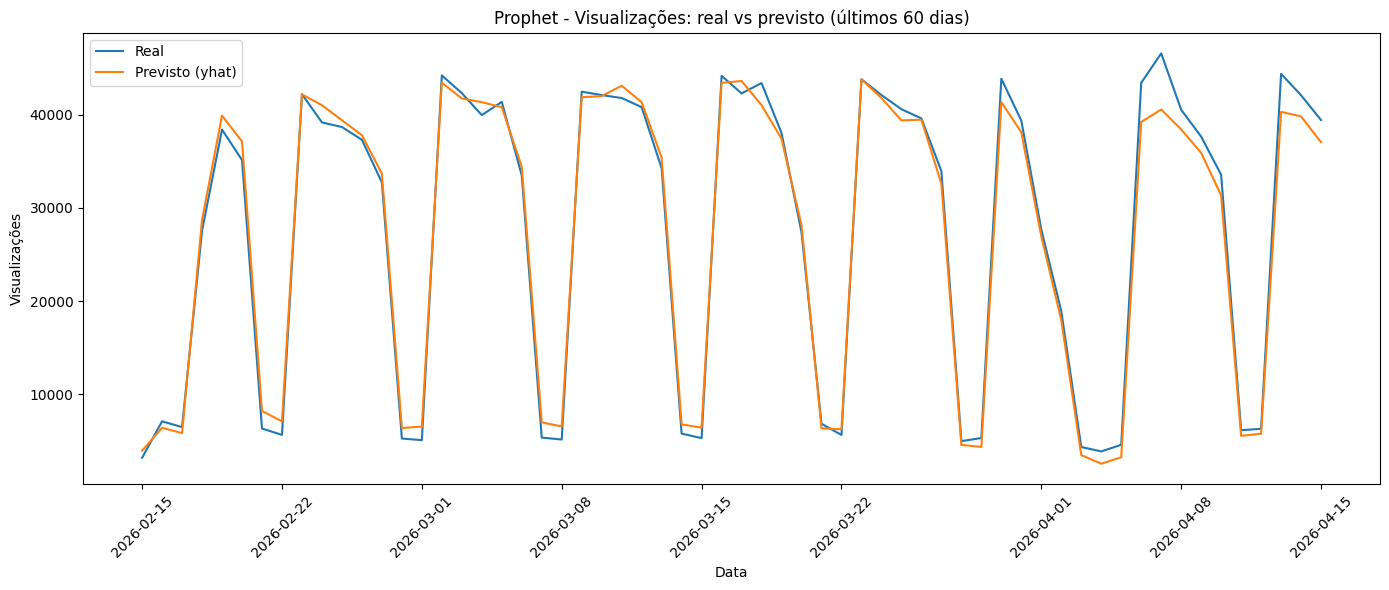

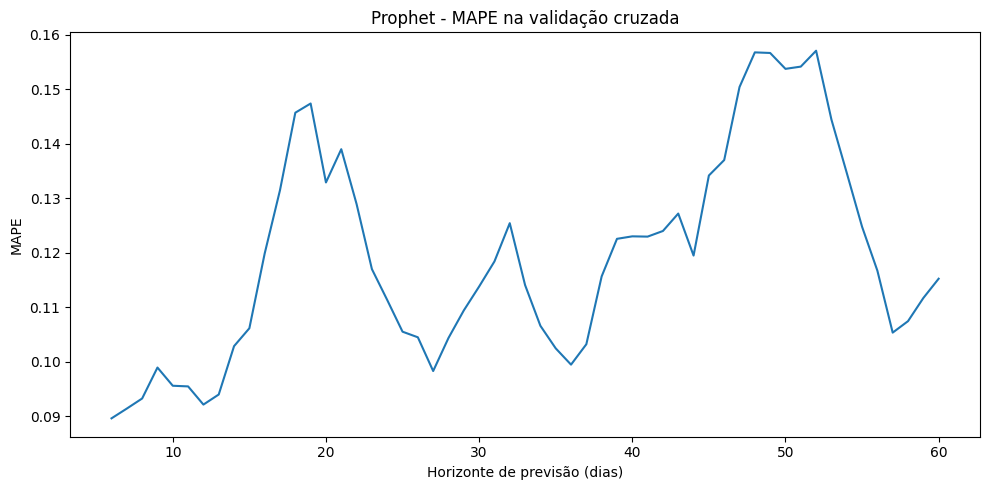

In [ ]:
# ============================================================
# Configuração
# ============================================================
# Foram mantidas as variáveis de tráfego e de calendário disponíveis,
# incluindo fim_de_semana, sessões e usuários ativos, conforme orientação metodológica.

regressores = [
    "sessoes",
    "usuarios_ativos",
    "fim_de_semana",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

dias_teste = 60

# ============================================================
# 3. Funções auxiliares
# ============================================================
def calcular_mape(y_true, y_pred):
    """Retorna o MAPE em porcentagem."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Proteção contra divisão por zero
    mascara = y_true != 0
    return np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100


def criar_modelo_prophet():
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative'
    )

    for reg in regressores:
        modelo.add_regressor(reg)

    return modelo


# ============================================================
# 4. Separação treino / teste holdout
# ============================================================
colunas_modelo = ['ds', 'y'] + regressores

train = df.iloc[:-dias_teste][colunas_modelo].copy()
test = df.iloc[-dias_teste:][colunas_modelo].copy()

# ============================================================
# 5. Treinamento e previsão holdout
# ============================================================
modelo = criar_modelo_prophet()
modelo.fit(train)

forecast_test = modelo.predict(test[['ds'] + regressores])

y_real = test['y'].values
y_prev = forecast_test['yhat'].values

rmse_holdout = np.sqrt(mean_squared_error(y_real, y_prev))
mae_holdout = mean_absolute_error(y_real, y_prev)
mape_holdout = calcular_mape(y_real, y_prev)
r2_holdout = r2_score(y_real, y_prev)

print("=" * 60)
print("AVALIAÇÃO HOLDOUT - ÚLTIMOS 60 DIAS")
print("=" * 60)
print(f"RMSE: {rmse_holdout:.2f}")
print(f"MAE : {mae_holdout:.2f}")
print(f"MAPE: {mape_holdout:.2f}%")
print(f"R²  : {r2_holdout:.4f}")

# ============================================================
# 6. Validação cruzada temporal do Prophet
# ============================================================
modelo_cv = criar_modelo_prophet()
modelo_cv.fit(df[colunas_modelo])

df_cv = cross_validation(
    modelo_cv,
    initial='730 days',
    period='30 days',
    horizon='60 days',
    parallel=None
)

# Métricas agregadas em todas as previsões fora da amostra da CV
rmse_cv = np.sqrt(mean_squared_error(df_cv['y'], df_cv['yhat']))
mae_cv = mean_absolute_error(df_cv['y'], df_cv['yhat'])
mape_cv = calcular_mape(df_cv['y'], df_cv['yhat'])
r2_cv = r2_score(df_cv['y'], df_cv['yhat'])

print("\n" + "=" * 60)
print("VALIDAÇÃO CRUZADA TEMPORAL - RESULTADO AGREGADO")
print("=" * 60)
print(f"RMSE: {rmse_cv:.2f}")
print(f"MAE : {mae_cv:.2f}")
print(f"MAPE: {mape_cv:.2f}%")
print(f"R²  : {r2_cv:.4f}")

# Métricas por horizonte usando a função nativa do Prophet
# rolling_window=0.1: curva suavizada por janela móvel
# rolling_window=1: tudo agregado em um ponto
# Aqui usamos 0.1 para gerar uma curva útil para gráfico.
df_metricas_cv = performance_metrics(df_cv, rolling_window=0.1)

print("\n" + "=" * 60)
print("MÉTRICAS NATIVAS DO PROPHET (CV)")
print("=" * 60)
print(df_metricas_cv[['horizon', 'rmse', 'mae', 'mape', 'coverage']])

# ============================================================
# 7. Gráficos
# ============================================================
# 7.1. Comparação real vs previsto no holdout
plt.figure(figsize=(14, 6))
plt.plot(test['ds'], y_real, label='Real')
plt.plot(test['ds'], y_prev, label='Previsto (yhat)')
plt.title('Prophet - Visualizações: real vs previsto (últimos 60 dias)')
plt.xlabel('Data')
plt.ylabel('Visualizações')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7.2. Curva de erro MAPE da validação cruzada
# Evita plot_cross_validation_metric(), que pode falhar em versões novas do pandas.
df_plot = df_metricas_cv.copy()
df_plot['horizon_dias'] = df_plot['horizon'].dt.days

plt.figure(figsize=(10, 5))
plt.plot(df_plot['horizon_dias'], df_plot['mape'])
plt.title('Prophet - MAPE na validação cruzada')
plt.xlabel('Horizonte de previsão (dias)')
plt.ylabel('MAPE')
plt.tight_layout()
plt.show()


## Salvamento de métricas do Prophet em CSV para comparação futura

In [4]:
metricas_prophet = pd.DataFrame({
    "modelo": ["Prophet Holdout", "Prophet CV"],
    "rmse": [rmse_holdout, rmse_cv],
    "mae": [mae_holdout, mae_cv],
    "mape": [mape_holdout, mape_cv],
    "r2": [r2_holdout, r2_cv]
})

metricas_prophet.to_csv("../dados/metricas_prophet.csv", index=False)

print("Métricas salvas em: ../dados/metricas_prophet.csv")
metricas_prophet

Métricas salvas em: ../dados/metricas_prophet.csv


,modelo,rmse,mae,mape,r2
0,Prophet Holdout,1629.895353,1267.701135,8.906494,0.990045
1,Prophet CV,3306.140497,2455.545989,11.826208,0.964105
